## VISUALIZACION DEL DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/DATASETPDI"
TRAIN_DIR = BASE_DIR + "/train"
TEST_DIR  = BASE_DIR + "/test"

print("Directorio base:", BASE_DIR)
print("Train folder:", TRAIN_DIR)
print("Test folder:", TEST_DIR)


Directorio base: /content/drive/MyDrive/DATASETPDI
Train folder: /content/drive/MyDrive/DATASETPDI/train
Test folder: /content/drive/MyDrive/DATASETPDI/test


In [ ]:
import glob

def contar_imagenes(ruta):
    extensiones = ("*.jpg","*.jpeg","*.png")
    total = 0
    for ext in extensiones:
        total += len(glob.glob(os.path.join(ruta, ext)))
    return total

for tipo, ruta in [("TRAIN", TRAIN_DIR), ("TEST", TEST_DIR)]:
    print(f"\n=== {tipo} ===")
    for clase in ["CIELO", "ESTRUCTURA"]:
        carpeta = os.path.join(ruta, clase)
        n = contar_imagenes(carpeta)
        print(f"{clase}: {n} imágenes")



=== TRAIN ===
CIELO: 100 imágenes
ESTRUCTURA: 120 imágenes

=== TEST ===
CIELO: 25 imágenes
ESTRUCTURA: 30 imágenes


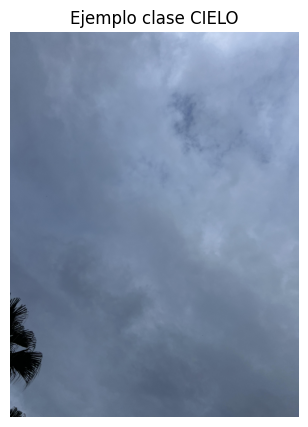

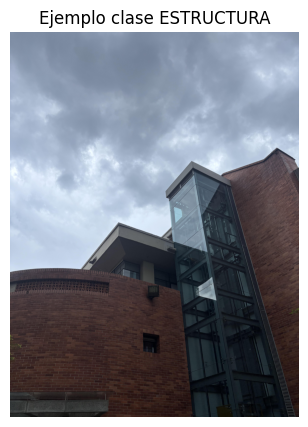

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

def ver_ejemplo(ruta, titulo):
    archivos = [f for f in os.listdir(ruta) if f.lower().endswith((".jpg",".png",".jpeg"))]
    img_path = os.path.join(ruta, random.choice(archivos))

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

# Ejemplos desde train
ver_ejemplo(TRAIN_DIR + "/CIELO", "Ejemplo clase CIELO")
ver_ejemplo(TRAIN_DIR + "/ESTRUCTURA", "Ejemplo clase ESTRUCTURA")


## PROCESAMIENTO CLASICO

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Filtro gaussiano para suavizar
def filtro_gaussiano(img):
    return cv2.GaussianBlur(img, (7,7), 0)

# 2. Conversión HSV para detectar cielo
def segmentar_cielo(img):
    img_blur = filtro_gaussiano(img)
    hsv = cv2.cvtColor(img_blur, cv2.COLOR_BGR2HSV)

    lower = np.array([80, 30, 50])
    upper = np.array([140, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    # morfología
    kernel = np.ones((7,7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

# 3. Contornos para estructuras
def segmentar_estructura(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 60, 150)

    # morfología
    kernel = np.ones((5,5), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=2)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    return edges

# ----- Visualización -----

ejemplo = cv2.imread(TRAIN_DIR + "/CIELO/" + random.choice(os.listdir(TRAIN_DIR + "/CIELO")))
cielo_mask = segmentar_cielo(ejemplo)
estructura_mask = segmentar_estructura(ejemplo)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(ejemplo, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(cielo_mask, cmap="gray"); plt.title("Cielo segmentado"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(estructura_mask, cmap="gray"); plt.title("Estructura segmentada"); plt.axis("off")
plt.show()


NameError: name 'TRAIN_DIR' is not defined

Para este proyecto se implementó un conjunto de técnicas de procesamiento digital clásico con el fin de mejorar la calidad de las imágenes, facilitar la detección de regiones de interés y preparar adecuadamente los datos para el modelo de segmentación posterior. Cada técnica elegida cumple una función específica y complementaria dentro del flujo de procesamiento.

Filtro Gaussiano (Reducción de ruido)
Se aplica un filtro Gaussiano para suavizar la imagen y eliminar ruido de alta frecuencia generado por el sensor o la iluminación. Este filtro atenúa variaciones bruscas sin eliminar la estructura de la imagen, preservando bordes importantes. La reducción de ruido es fundamental para evitar falsos contornos y para estabilizar tanto la segmentación basada en color como los detectores de bordes.

Conversión de color a espacio HSV (Separación de información cromática)
El espacio HSV permite separar la información de tono, saturación y brillo, lo que facilita la extracción de elementos como el cielo, que presenta tonalidades específicas (azules, celestes o grises). Trabajar en HSV permite aplicar umbrales más consistentes y robustos que en RGB, ya que la iluminación variable afecta mucho menos a la componente Hue. Esta conversión mejora la precisión de las máscaras iniciales de cielo.

Detección de bordes con Canny (Resaltado de límites estructurales)
Se utiliza el algoritmo Canny para resaltar los bordes más relevantes de la imagen, lo cual es particularmente útil para la segmentación de estructuras como edificios, columnas, postes o techos. Canny proporciona bordes delgados y continuos, perfectos para distinguir objetos físicos de gran contraste frente al cielo o el fondo. El suavizado previo con Gaussiano mejora significativamente los resultados de Canny.

Operaciones morfológicas (Limpieza y refinamiento de máscaras)
Luego de generar las primeras máscaras, se aplican operaciones morfológicas como erosión, dilatación y cierre para eliminar ruido residual, rellenar huecos y mejorar la continuidad de las regiones segmentadas. Estas operaciones permiten crear máscaras más limpias y estables, adecuadas para generar polígonos que posteriormente se utilizan en la creación del dataset YOLO-Seg.

En conjunto, estas técnicas clásicas producen una segmentación inicial eficiente y robusta, la cual sirve como base para generar las etiquetas necesarias para entrenar el modelo de segmentación profundo. Además, el procesamiento clásico asegura mayor estabilidad ante variaciones de iluminación y texturas, mejorando la calidad de los datos y optimizando el rendimiento del modelo final.

## MODELO DE SEGMENTACION POR INSTANCIAS

In [ ]:
!pip install numpy==1.26.4 --force-reinstall --no-cache-dir -q
!pip install ultralytics==8.3.0 opencv-python-headless==4.10.0.84 matplotlib -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 377.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt


In [ ]:
# Ruta a tu dataset ORIGINAL (imagenes sin anotaciones YOLO)
ORIG_DATASET = "/content/drive/MyDrive/DATASETPDI"  # <-- ya la usaste

# Nuevo dataset YOLO-Seg mejorado
OUTPUT_DIR = "/content/DATASETPDI_YOLOSEG_V2"

os.makedirs(OUTPUT_DIR, exist_ok=True)
for split in ["train", "test"]:
    os.makedirs(f"{OUTPUT_DIR}/{split}/images", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/{split}/labels", exist_ok=True)

print("Estructura creada en:", OUTPUT_DIR)
print("Splits:", os.listdir(OUTPUT_DIR))


Estructura creada en: /content/DATASETPDI_YOLOSEG_V2
Splits: ['train', 'test']


In [ ]:
def segmentar_cielo(img):
    """
    Segmentación de cielo usando HSV.
    Ajustable, pero ligera y estable.
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Rango de cielo (azules / celestes) – puedes ajustar si ves errores
    lower = np.array([80, 10, 80])   # H, S, V
    upper = np.array([140, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)

    # Suavizado y limpieza
    mask = cv2.GaussianBlur(mask, (7, 7), 0)

    # Binarizar fuerte
    _, mask = cv2.threshold(mask, 50, 255, cv2.THRESH_BINARY)

    # Cerrar huecos y eliminar ruido
    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    return (mask > 0).astype(np.uint8)


In [ ]:
def segmentar_estructura(img):
    """
    Segmentación rápida de estructuras (edificios, postes, árboles grandes)
    usando Canny + dilatación + relleno.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Suavizar
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Bordes
    edges = cv2.Canny(blur, 40, 120)

    # Dilatar bordes para conectar líneas
    kernel = np.ones((5, 5), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=2)

    # Rellenar regiones cerradas: floodfill desde los bordes
    h, w = edges.shape
    mask_ff = np.zeros((h+2, w+2), np.uint8)
    fill = edges.copy()
    cv2.floodFill(fill, mask_ff, (0, 0), 255)
    fill_inv = cv2.bitwise_not(fill)

    # Combinar edges + regiones cerradas
    mask = cv2.bitwise_or(edges, fill_inv)

    # Binarizar y limpiar
    _, mask = cv2.threshold(mask, 50, 255, cv2.THRESH_BINARY)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    return (mask > 0).astype(np.uint8)


In [ ]:
def mask_to_yolo(mask, w, h,
                 min_area_ratio=0.001,
                 epsilon_ratio=0.01,
                 max_points=200):
    """
    Convierte máscara binaria -> lista de polígonos normalizados para YOLO-Seg.

    - min_area_ratio: mínimo área relativa para aceptar un contorno
    - epsilon_ratio: nivel de simplificación (0.01 = suave, 0.05 = muy simplificado)
    - max_points: máximo de puntos por polígono
    """
    contours, _ = cv2.findContours(mask.astype(np.uint8),
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    polys = []
    img_area = float(w * h)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < img_area * min_area_ratio:
            # Demasiado pequeño -> ruido
            continue

        # Simplificar contorno
        epsilon = epsilon_ratio * cv2.arcLength(cnt, True)
        cnt = cv2.approxPolyDP(cnt, epsilon, True)

        # Asegurar máximo de puntos
        if len(cnt) > max_points:
            idx = np.linspace(0, len(cnt)-1, max_points).astype(int)
            cnt = cnt[idx]

        # A float para normalizar
        cnt = cnt.reshape(-1, 2).astype(float)

        # Normalizar a [0,1]
        cnt[:, 0] /= w
        cnt[:, 1] /= h

        polys.append(cnt.tolist())

    return polys


In [ ]:
def procesar_split(split):
    """
    Lee imágenes de ORIG_DATASET/split/(CIELO|ESTRUCTURA)
    Genera:
      - imágenes en OUTPUT_DIR/split/images
      - etiquetas YOLO-Seg en OUTPUT_DIR/split/labels
    """
    print(f"\nProcesando {split}...")

    for clase in ["CIELO", "ESTRUCTURA"]:
        carpeta = f"{ORIG_DATASET}/{split}/{clase}"
        img_files = sorted([
            f for f in os.listdir(carpeta)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        print(f"  Clase {clase}: {len(img_files)} imágenes")

        for idx, img_name in enumerate(img_files):
            print(f"\r    ({idx+1}/{len(img_files)}) -> {img_name}", end="")

            path = f"{carpeta}/{img_name}"
            img = cv2.imread(path)
            if img is None:
                continue
            h, w = img.shape[:2]

            # === 1. Segmentaciones mejoradas ===
            cielo_mask = segmentar_cielo(img)
            struct_mask = segmentar_estructura(img)

            # === 2. Guardar imagen (solo una copia, sirve para ambas clases) ===
            out_img_path = f"{OUTPUT_DIR}/{split}/images/{img_name}"
            cv2.imwrite(out_img_path, img)

            # === 3. Construir etiqueta YOLO-Seg ===
            out_lbl = f"{OUTPUT_DIR}/{split}/labels/{img_name[:-4]}.txt"
            with open(out_lbl, "w") as f:
                # Clase 0 -> cielo
                polys_cielo = mask_to_yolo(cielo_mask, w, h)
                for p in polys_cielo:
                    f.write("0 " + " ".join(f"{x:.6f} {y:.6f}" for x, y in p) + "\n")

                # Clase 1 -> estructura
                polys_struct = mask_to_yolo(struct_mask, w, h)
                for p in polys_struct:
                    f.write("1 " + " ".join(f"{x:.6f} {y:.6f}" for x, y in p) + "\n")

        print(f"\n  -> Split {split} completado.")


In [ ]:
procesar_split("train")
procesar_split("test")
print("\nDataset YOLO-Seg mejorado generado en:", OUTPUT_DIR)



Procesando train...
  Clase CIELO: 100 imágenes
    (100/100) -> IMG_6527.jpg
  -> Split train completado.
  Clase ESTRUCTURA: 120 imágenes
    (120/120) -> IMG_6538.jpg
  -> Split train completado.

Procesando test...
  Clase CIELO: 25 imágenes
    (25/25) -> IMG_5878.jpg
  -> Split test completado.
  Clase ESTRUCTURA: 30 imágenes
    (30/30) -> IMG_6496.jpg
  -> Split test completado.

Dataset YOLO-Seg mejorado generado en: /content/DATASETPDI_YOLOSEG_V2


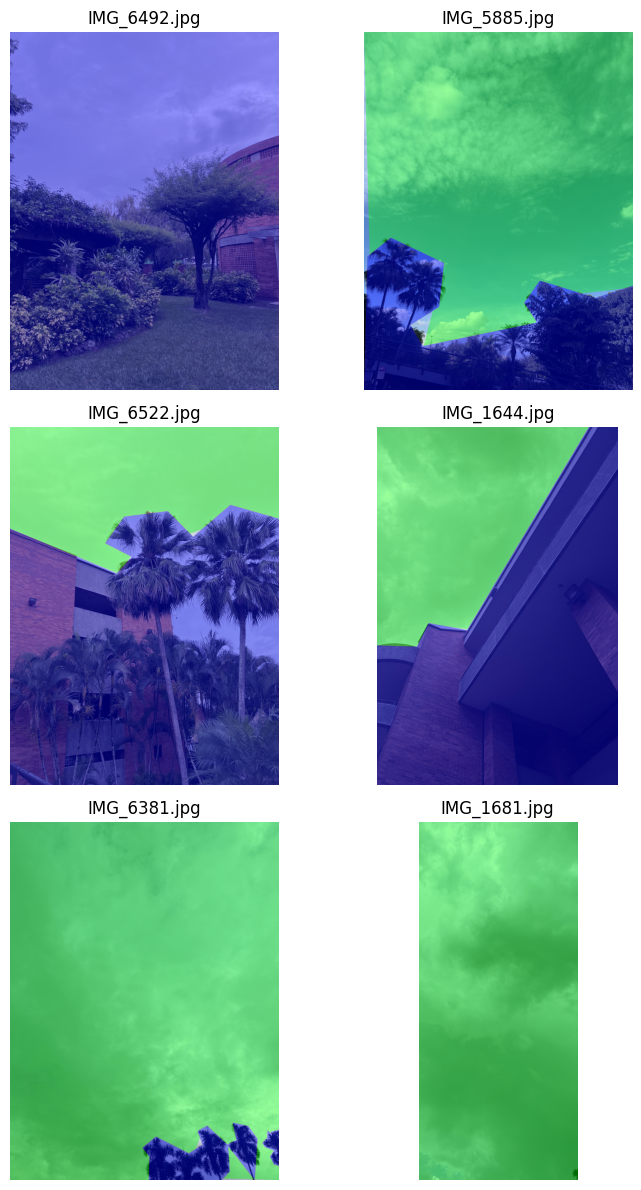

In [ ]:
def mostrar_overlay(sample_split="train", n=4):
    import random
    folder_img = f"{OUTPUT_DIR}/{sample_split}/images"
    files = [f for f in os.listdir(folder_img) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(files, min(n, len(files)))

    cols = 2
    rows = int(np.ceil(len(sample) / cols))
    plt.figure(figsize=(8, 4*rows))

    for i, img_name in enumerate(sample, 1):
        img_path = f"{OUTPUT_DIR}/{sample_split}/images/{img_name}"
        lbl_path = f"{OUTPUT_DIR}/{sample_split}/labels/{img_name[:-4]}.txt"

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        overlay = img.copy()

        # leer polígonos YOLO y pintarlos
        if os.path.exists(lbl_path):
            with open(lbl_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    cls = int(parts[0])
                    coords = np.array(list(map(float, parts[1:])), dtype=float).reshape(-1, 2)
                    pts = coords.copy()
                    pts[:, 0] *= w
                    pts[:, 1] *= h
                    pts = pts.astype(int)

                    color = (0, 255, 0) if cls == 0 else (255, 0, 0)  # cielo verde, estructura rojo
                    cv2.polylines(overlay, [pts], isClosed=True, color=color, thickness=2)
                    cv2.fillPoly(overlay, [pts], color=color[::-1] + (50,) if len(color)==3 else color)

        alpha = 0.4
        vis = cv2.addWeighted(overlay, alpha, img, 1-alpha, 0)

        plt.subplot(rows, cols, i)
        plt.imshow(vis)
        plt.axis('off')
        plt.title(img_name)

    plt.tight_layout()
    plt.show()

mostrar_overlay("train", n=6)


## entrenamiento yolo

In [ ]:
yaml_text = """
path: /content/drive/MyDrive/DATASETPDI_YOLOSEG

train: images/train
val: images/train
test: images/train

names:
  0: cielo
  1: estructura
"""

with open("data_seg_final.yaml", "w") as f:
    f.write(yaml_text)

print(open("data_seg_final.yaml").read())



path: /content/drive/MyDrive/DATASETPDI_YOLOSEG

train: images/train
val: images/train
test: images/train

names:
  0: cielo
  1: estructura



In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

model.train(
    data="data_seg_final.yaml",
    imgsz=640,
    epochs=80,
    batch=4
)


New https://pypi.org/project/ultralytics/8.3.228 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=data_seg_final.yaml, epochs=80, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train17, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=F

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter: